# Yoga Pose Classification Using Convolutional Neural Networks and Transfer Learning

## Overview

This notebook develops an image-based yoga pose classification framework using deep learning techniques. Two models are investigated:

- Custom Convolutional Neural Network (CNN)
- MobileNetV2 Transfer Learning

The framework classifies five yoga poses:

1. Downward Dog
2. Goddess
3. Plank
4. Tree
5. Warrior II

The workflow includes:

- Dataset cleaning
- Exploratory analysis
- Data augmentation
- Model development
- Transfer learning
- Performance evaluation
- Error analysis
- Comparative assessment

## Objective

To evaluate the effectiveness of transfer learning compared with a conventional CNN architecture for yoga pose recognition.

In [1]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

RAW_BASE = "/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET"

PROJECT_DIR = "/kaggle/working/Yoga-Pose-Recognition"
FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
MODEL_DIR = os.path.join(PROJECT_DIR, "Models")
RESULT_DIR = os.path.join(PROJECT_DIR, "Results")
CLEAN_BASE = os.path.join(PROJECT_DIR, "Clean_Dataset")

for folder in [PROJECT_DIR, FIGURE_DIR, MODEL_DIR, RESULT_DIR, CLEAN_BASE]:
    os.makedirs(folder, exist_ok=True)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
NUM_CLASSES = 5

class_names = ["downdog", "goddess", "plank", "tree", "warrior2"]

display_names = {
    "downdog": "Downward Dog",
    "goddess": "Goddess",
    "plank": "Plank",
    "tree": "Tree",
    "warrior2": "Warrior II"
}

print("Setup completed successfully.")
print("TensorFlow version:", tf.__version__)
print("Dataset path:", RAW_BASE)

2026-06-03 05:46:34.324132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780465594.550095      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780465594.618591      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780465595.151283      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780465595.151324      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780465595.151326      23 computation_placer.cc:177] computation placer alr

Setup completed successfully.
TensorFlow version: 2.19.0
Dataset path: /kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET


In [2]:
# ============================================================
# Cell 3: Clean Dataset
# ============================================================

clean_count = 0
bad_files = []

for split in ["TRAIN", "TEST"]:
    split_path = os.path.join(RAW_BASE, split)

    for cls in class_names:
        in_dir = os.path.join(split_path, cls)
        out_dir = os.path.join(CLEAN_BASE, split, cls)

        os.makedirs(out_dir, exist_ok=True)

        for file in os.listdir(in_dir):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                in_path = os.path.join(in_dir, file)
                out_path = os.path.join(out_dir, os.path.splitext(file)[0] + ".jpg")

                try:
                    img = Image.open(in_path).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    img.save(out_path, "JPEG", quality=95)
                    clean_count += 1

                except Exception as error:
                    bad_files.append({
                        "split": split,
                        "class": cls,
                        "file": file,
                        "error": str(error)
                    })

bad_files_df = pd.DataFrame(bad_files)

bad_files_df.to_csv(
    os.path.join(RESULT_DIR, "bad_files_report.csv"),
    index=False
)

print("Clean images saved:", clean_count)
print("Bad files skipped:", len(bad_files))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Clean images saved: 1550
Bad files skipped: 0


In [3]:
# ============================================================
# Cell 4: Dataset Statistics
# ============================================================

records = []

for split in ["TRAIN", "TEST"]:
    for cls in class_names:
        folder = os.path.join(CLEAN_BASE, split, cls)
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(".jpg")
        ])

        records.append({
            "Split": split,
            "Class": display_names[cls],
            "Number of Images": count
        })

dataset_stats = pd.DataFrame(records)

dataset_stats.to_excel(
    os.path.join(RESULT_DIR, "dataset_statistics.xlsx"),
    index=False
)

display(dataset_stats)

print("Dataset statistics saved.")

,Split,Class,Number of Images
0,TRAIN,Downward Dog,222
1,TRAIN,Goddess,180
2,TRAIN,Plank,266
3,TRAIN,Tree,160
4,TRAIN,Warrior II,252
5,TEST,Downward Dog,97
6,TEST,Goddess,80
7,TEST,Plank,115
8,TEST,Tree,69
9,TEST,Warrior II,109


Dataset statistics saved.


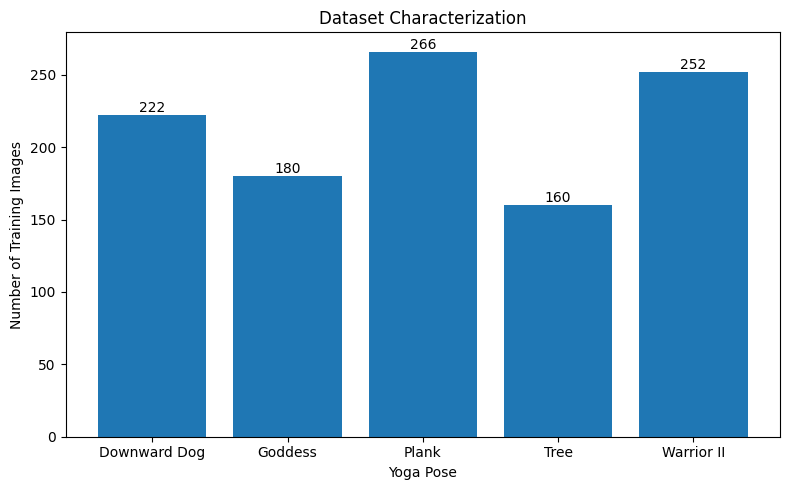

Dataset characterization figure saved.


In [4]:
# ============================================================
# Cell 5: Dataset Characterization Figure
# ============================================================

train_stats = dataset_stats[dataset_stats["Split"] == "TRAIN"]

plt.figure(figsize=(8,5))

bars = plt.bar(
    train_stats["Class"],
    train_stats["Number of Images"]
)

plt.title("Dataset Characterization")
plt.xlabel("Yoga Pose")
plt.ylabel("Number of Training Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "dataset_characterization_dashboard.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Dataset characterization figure saved.")

In [5]:
# ============================================================
# Restore Output Directories
# ============================================================

import os

PROJECT_DIR = "/kaggle/working/Yoga-Pose-Recognition"

FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
RESULT_DIR = os.path.join(PROJECT_DIR, "Results")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Directories restored.")
print(FIGURE_DIR)
print(RESULT_DIR)

Directories restored.
/kaggle/working/Yoga-Pose-Recognition/Figures
/kaggle/working/Yoga-Pose-Recognition/Results


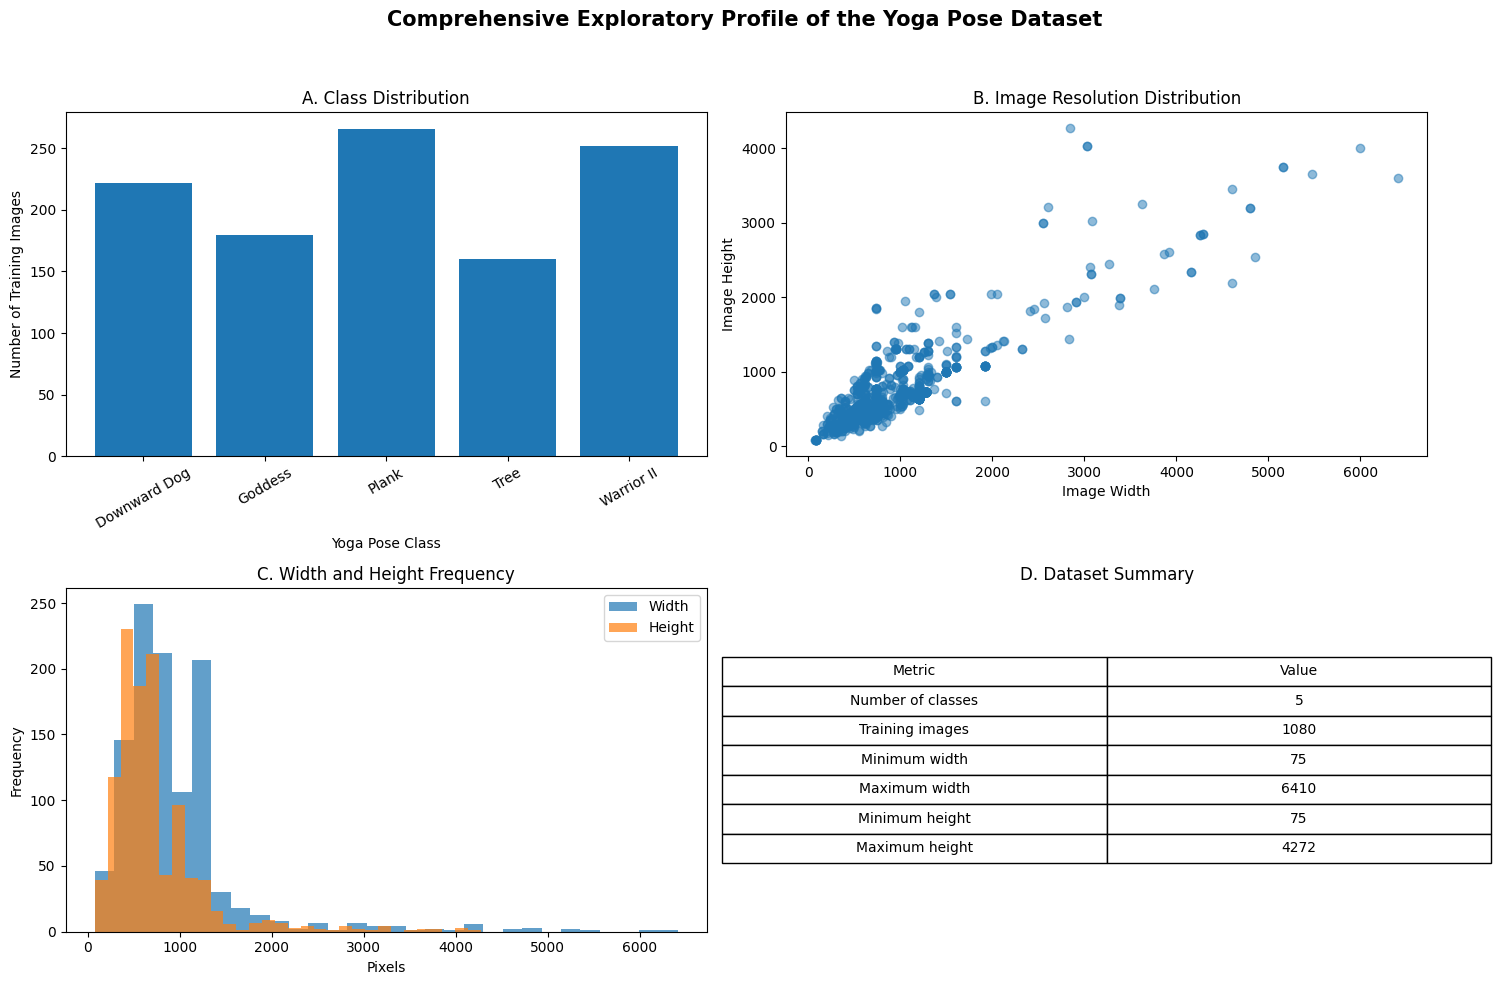

,Metric,Value
0,Number of classes,5
1,Training images,1080
2,Minimum width,75
3,Maximum width,6410
4,Minimum height,75
5,Maximum height,4272


Comprehensive exploratory profile saved.


In [6]:
# ============================================================
# Cell 5: Comprehensive Exploratory Profile of the Dataset
# ============================================================

eda_records = []

for cls in class_names:
    folder = os.path.join(RAW_BASE, "TRAIN", cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(folder, file)

            try:
                img = Image.open(image_path)
                width, height = img.size

                eda_records.append({
                    "class": cls,
                    "image_path": image_path,
                    "width": width,
                    "height": height
                })

            except Exception as error:
                pass

df = pd.DataFrame(eda_records)

df["display_class"] = df["class"].map(display_names)

class_counts = df["display_class"].value_counts().reindex([
    "Downward Dog",
    "Goddess",
    "Plank",
    "Tree",
    "Warrior II"
])

summary = pd.DataFrame({
    "Metric": [
        "Number of classes",
        "Training images",
        "Minimum width",
        "Maximum width",
        "Minimum height",
        "Maximum height"
    ],
    "Value": [
        df["display_class"].nunique(),
        len(df),
        df["width"].min(),
        df["width"].max(),
        df["height"].min(),
        df["height"].max()
    ]
})

class_counts.to_csv(
    os.path.join(RESULT_DIR, "train_class_distribution.csv")
)

summary.to_excel(
    os.path.join(RESULT_DIR, "dataset_summary.xlsx"),
    index=False
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle(
    "Comprehensive Exploratory Profile of the Yoga Pose Dataset",
    fontsize=15,
    fontweight="bold"
)

axes[0, 0].bar(
    class_counts.index,
    class_counts.values
)

axes[0, 0].set_title("A. Class Distribution")
axes[0, 0].set_xlabel("Yoga Pose Class")
axes[0, 0].set_ylabel("Number of Training Images")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].scatter(
    df["width"],
    df["height"],
    alpha=0.5
)

axes[0, 1].set_title("B. Image Resolution Distribution")
axes[0, 1].set_xlabel("Image Width")
axes[0, 1].set_ylabel("Image Height")

axes[1, 0].hist(
    df["width"],
    bins=30,
    alpha=0.7,
    label="Width"
)

axes[1, 0].hist(
    df["height"],
    bins=30,
    alpha=0.7,
    label="Height"
)

axes[1, 0].set_title("C. Width and Height Frequency")
axes[1, 0].set_xlabel("Pixels")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

axes[1, 1].axis("off")
axes[1, 1].set_title("D. Dataset Summary")

table = axes[1, 1].table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "comprehensive_exploratory_profile.pdf"
    ),
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

display(summary)

print("Comprehensive exploratory profile saved.")

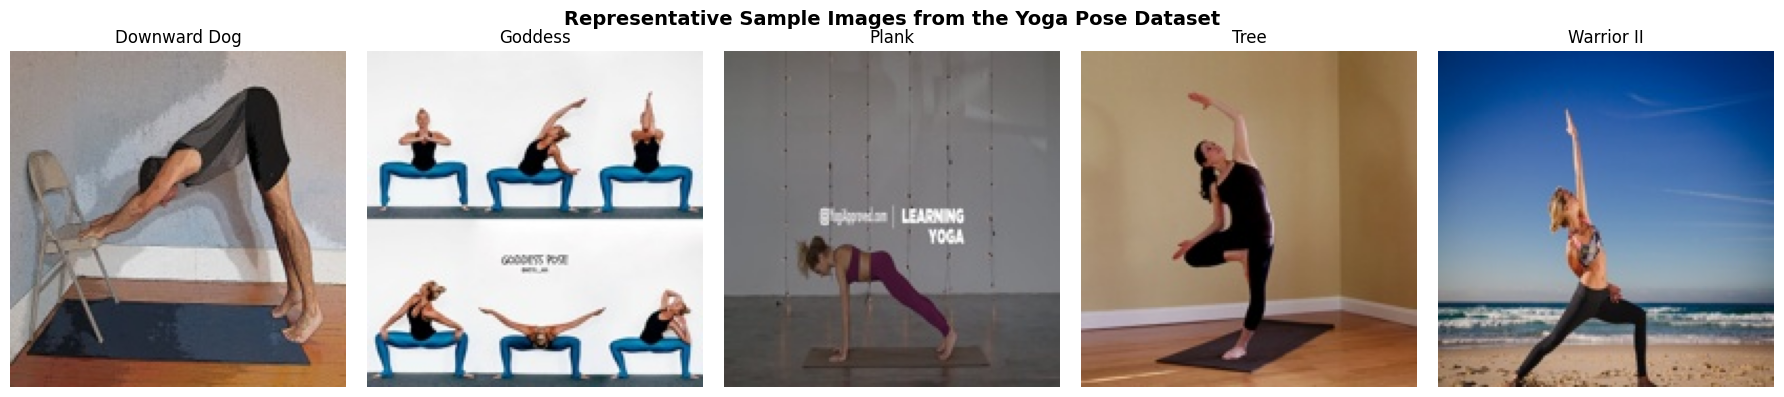

Representative sample images figure saved.


In [7]:
# ============================================================
# Cell 6: Representative Sample Images
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cls in enumerate(class_names):
    folder = os.path.join(CLEAN_BASE, "TRAIN", cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(".jpg")]

    sample_file = random.choice(files)
    image_path = os.path.join(folder, sample_file)

    img = Image.open(image_path).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(display_names[cls])
    axes[i].axis("off")

plt.suptitle("Representative Sample Images from the Yoga Pose Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "representative_sample_images.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Representative sample images figure saved.")

In [8]:
# ============================================================
# Cell 7: TensorFlow Data Pipeline
# ============================================================

train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TRAIN"),
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TRAIN"),
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TEST"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Training batches:", len(train_data))
print("Validation batches:", len(val_data))
print("Test batches:", len(test_data))
print("Data pipeline completed successfully.")

Found 1080 files belonging to 5 classes.
Using 864 files for training.


I0000 00:00:1780465663.925150      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780465663.931521      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1080 files belonging to 5 classes.
Using 216 files for validation.
Found 470 files belonging to 5 classes.
Training batches: 27
Validation batches: 7
Test batches: 15
Data pipeline completed successfully.


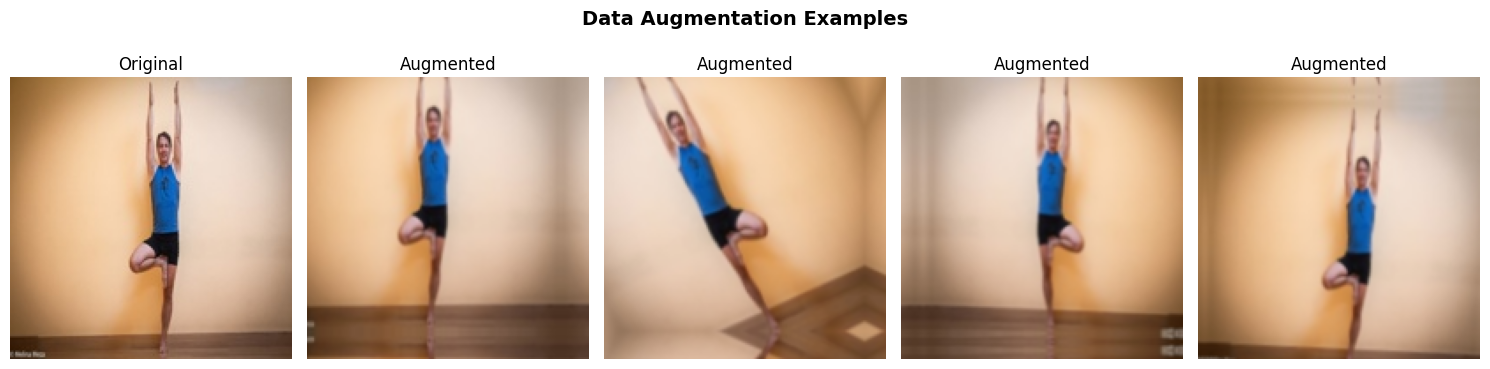

Data augmentation figure saved.


In [9]:
# ============================================================
# Cell 8: Data Augmentation Examples
# ============================================================

augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

sample_folder = os.path.join(CLEAN_BASE, "TRAIN", "tree")
sample_file = random.choice([
    f for f in os.listdir(sample_folder)
    if f.lower().endswith(".jpg")
])

sample_path = os.path.join(sample_folder, sample_file)

img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented_img = augmentation(
        tf.expand_dims(img_array, 0),
        training=True
    )

    axes[i].imshow(augmented_img[0].numpy().astype("uint8"))
    axes[i].set_title("Augmented")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "data_augmentation_examples.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Data augmentation figure saved.")

In [10]:
# ============================================================
# Cell 9: Custom CNN Model and Training
# ============================================================

custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

callbacks_cnn = [
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "custom_cnn_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(
        os.path.join(RESULT_DIR, "custom_cnn_training_log.csv"),
        append=False
    )
]

history_cnn = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=callbacks_cnn
)

custom_cnn.save(
    os.path.join(MODEL_DIR, "custom_cnn_final.keras")
)

print("Custom CNN training completed and saved.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8


I0000 00:00:1780465669.952884      77 service.cc:152] XLA service 0x447450c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780465669.952920      77 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780465669.952927      77 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780465670.349483      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


 7/27 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1862 - loss: 2.2379

I0000 00:00:1780465674.638087      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2369 - loss: 1.9282
Epoch 1: val_accuracy improved from None to 0.33796, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.2616 - loss: 1.7094 - val_accuracy: 0.3380 - val_loss: 1.6098
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3665 - loss: 1.5018
Epoch 2: val_accuracy improved from 0.33796 to 0.50926, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4005 - loss: 1.4352 - val_accuracy: 0.5093 - val_loss: 1.4289
Epoch 3/8
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5429 - loss: 1.2505
Epoch 3: val_accuracy improved from 0.50926 to

In [11]:
# ============================================================
# Cell 10: MobileNetV2 Transfer Learning
# ============================================================

base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

callbacks_mobilenet = [
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "mobilenetv2_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(
        os.path.join(RESULT_DIR, "mobilenetv2_training_log.csv"),
        append=False
    )
]

history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks_mobilenet
)

mobilenet_model.save(
    os.path.join(MODEL_DIR, "mobilenetv2_final.keras")
)

print("MobileNetV2 training completed and saved.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

...

Epoch 1/15


2026-06-03 05:48:20.857798: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:48:20.994751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2153 - loss: 2.1769

2026-06-03 05:48:36.521502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:48:36.659000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.33796, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras

Epoch 1: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 602ms/step - accuracy: 0.2454 - loss: 1.9613 - val_accuracy: 0.3380 - val_loss: 1.5517
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2640 - loss: 1.7603
Epoch 2: val_accuracy improved from 0.33796 to 0.47685, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras

Epoch 2: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3090 - loss: 1.6604 - val_accuracy: 0.4769 - val_loss: 1.3186
Epoch 3/15
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3834 - loss: 1.4845
Epoch 3: val_accuracy improved from 0.47685 to 0.55093, saving model to /kaggle/working/Yoga-Pose-Recognition/Mo

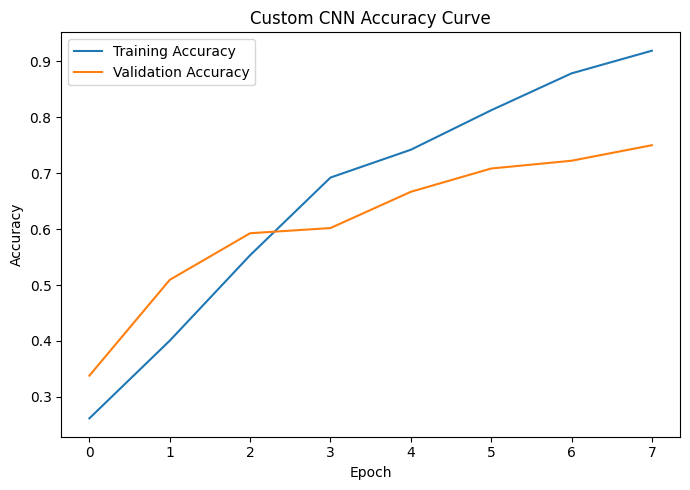

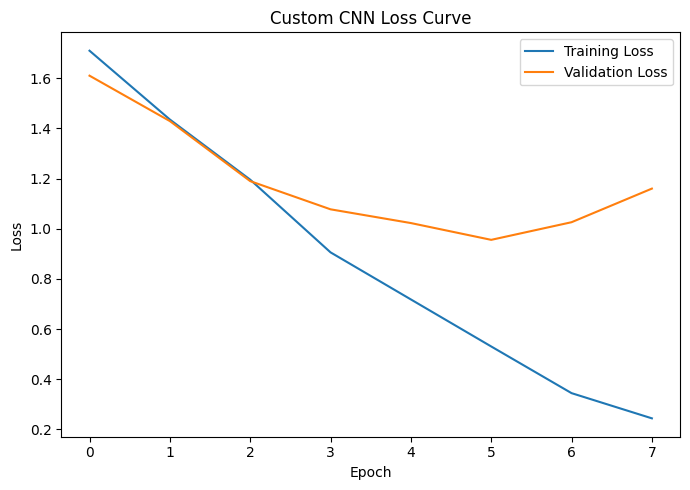

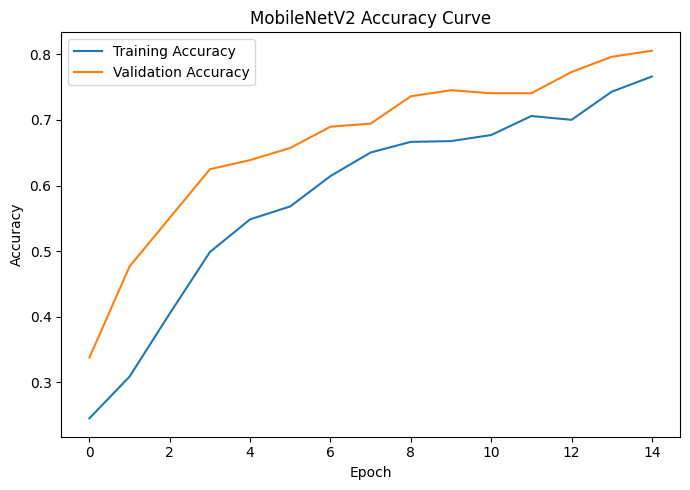

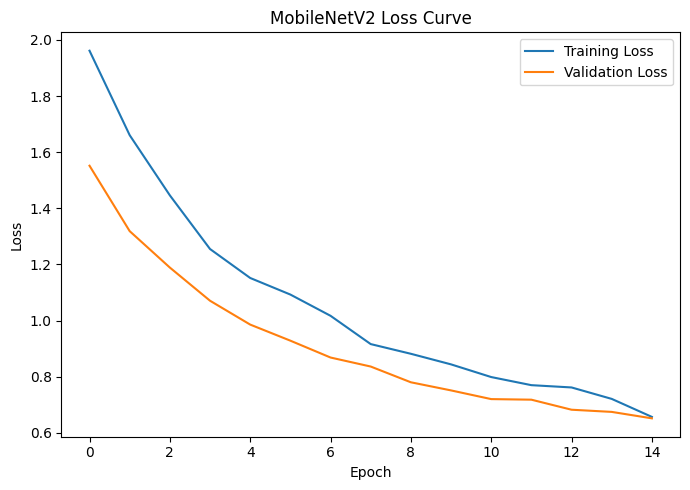

Training curves saved and displayed.


In [12]:
# ============================================================
# Cell 11: Training Curves
# ============================================================

custom_history_df = pd.DataFrame(history_cnn.history)
mobilenet_history_df = pd.DataFrame(history_mobilenet.history)

custom_history_df.to_excel(
    os.path.join(RESULT_DIR, "custom_cnn_history.xlsx"),
    index=False
)

mobilenet_history_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_history.xlsx"),
    index=False
)

plt.figure(figsize=(7,5))
plt.plot(custom_history_df["accuracy"], label="Training Accuracy")
plt.plot(custom_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "custom_cnn_accuracy_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(custom_history_df["loss"], label="Training Loss")
plt.plot(custom_history_df["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "custom_cnn_loss_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(mobilenet_history_df["accuracy"], label="Training Accuracy")
plt.plot(mobilenet_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "mobilenetv2_accuracy_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(mobilenet_history_df["loss"], label="Training Loss")
plt.plot(mobilenet_history_df["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "mobilenetv2_loss_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved and displayed.")

In [13]:
# ============================================================
# Cell 12: Final Evaluation
# ============================================================

y_true = np.concatenate([y for x, y in test_data], axis=0)

y_pred_prob = mobilenet_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=[display_names[c] for c in class_names],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_classification_report.xlsx")
)

print("Classification report saved.")

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

2026-06-03 05:49:09.140451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:49:09.287135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:49:09.424388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 810ms/step


,precision,recall,f1-score,support
Downward Dog,0.977528,0.896907,0.935484,97.000000
Goddess,0.757143,0.662500,0.706667,80.000000
Plank,0.900901,0.869565,0.884956,115.000000
Tree,0.773810,0.942029,0.849673,69.000000
Warrior II,0.810345,0.862385,0.835556,109.000000
accuracy,0.848936,0.848936,0.848936,0.848936
macro avg,0.843945,0.846677,0.842467,470.000000
weighted avg,0.852587,0.848936,0.848400,470.000000


Classification report saved.


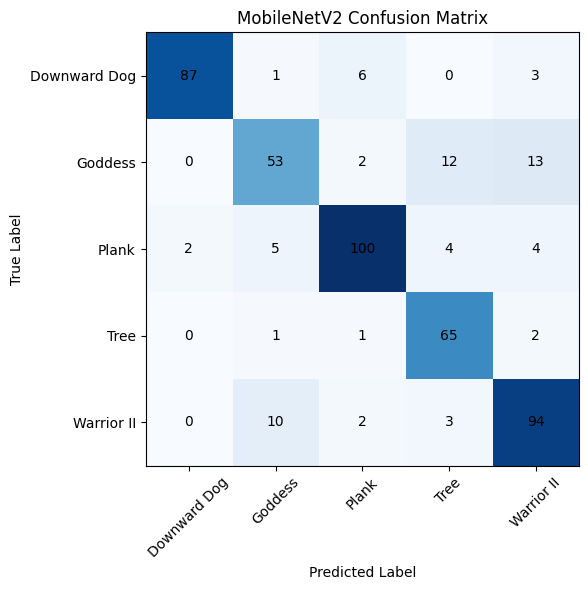

Confusion matrix saved.


In [14]:
# ============================================================
# Cell 13: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    [display_names[c] for c in class_names],
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    [display_names[c] for c in class_names]
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "mobilenetv2_confusion_matrix.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")

,Model,Test Accuracy,Test Loss
0,Custom CNN,78.936172,0.611854
1,MobileNetV2,84.893614,0.425764


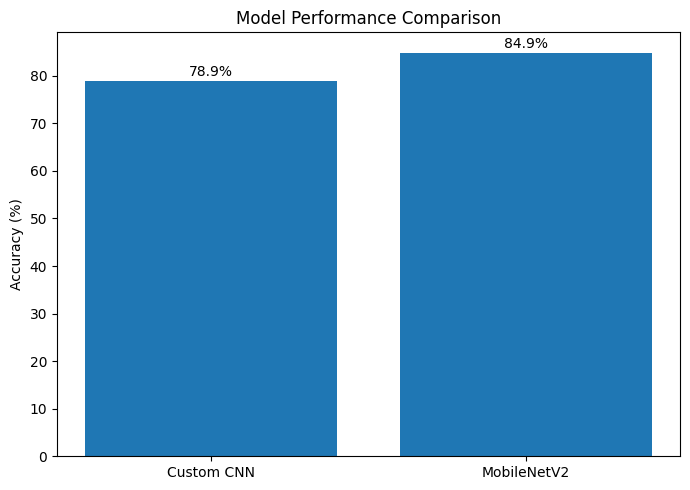

         Model  Test Accuracy  Test Loss
0   Custom CNN      78.936172   0.611854
1  MobileNetV2      84.893614   0.425764


In [15]:
# ============================================================
# Cell 14: Model Comparison
# ============================================================

custom_loss, custom_acc = custom_cnn.evaluate(
    test_data,
    verbose=0
)

mobile_loss, mobile_acc = mobilenet_model.evaluate(
    test_data,
    verbose=0
)

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [
        custom_acc * 100,
        mobile_acc * 100
    ],
    "Test Loss": [
        custom_loss,
        mobile_loss
    ]
})

display(comparison_df)

comparison_df.to_excel(
    os.path.join(
        RESULT_DIR,
        "model_comparison.xlsx"
    ),
    index=False
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "model_performance_comparison.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(comparison_df)

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step


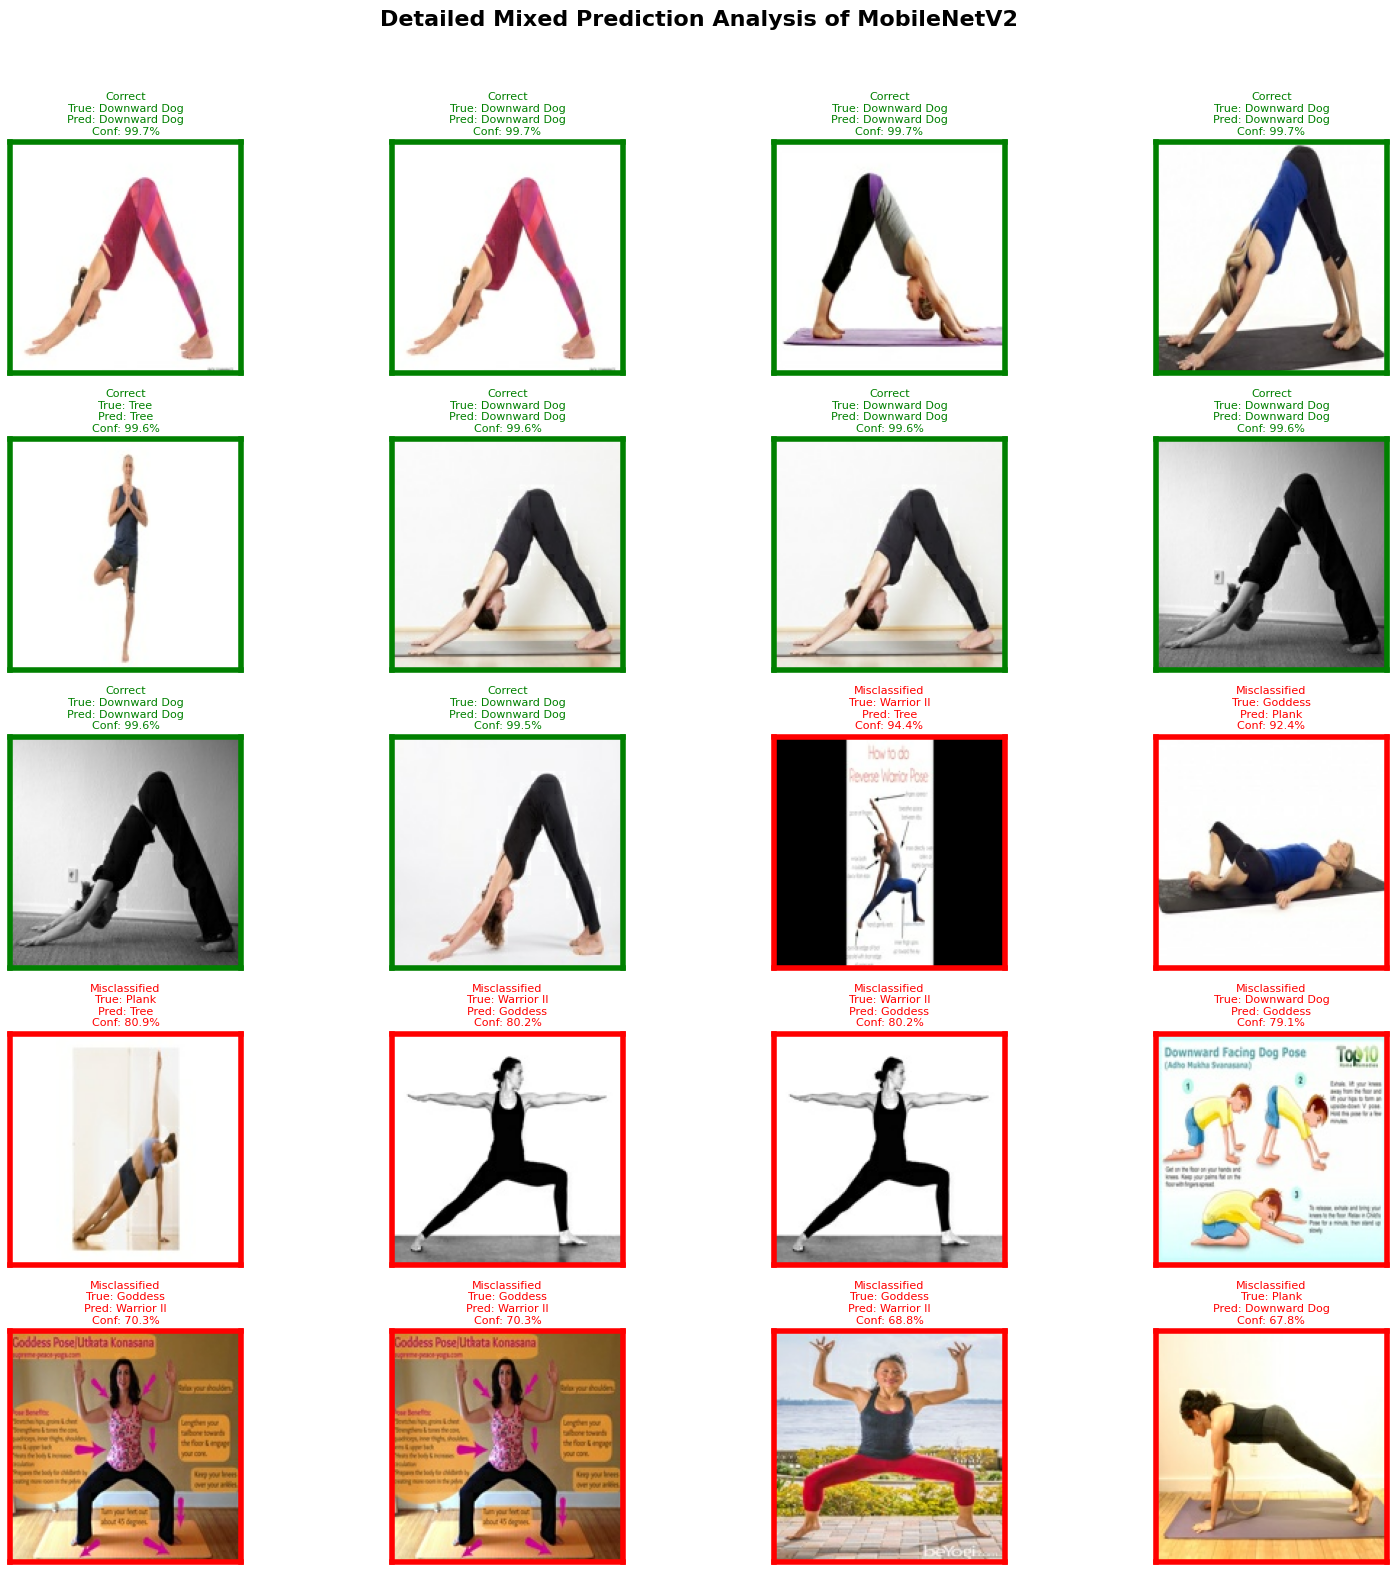

Detailed mixed prediction analysis figure saved.


In [16]:
# ============================================================
# Cell 15: Detailed Mixed Prediction Analysis
# ============================================================

all_images = []
all_labels = []

for x, y in test_data:
    all_images.append(x.numpy())
    all_labels.append(y.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

pred_probs_all = mobilenet_model.predict(all_images)
pred_labels_all = np.argmax(pred_probs_all, axis=1)
confidence_all = np.max(pred_probs_all, axis=1)

correct_indices = np.where(pred_labels_all == all_labels)[0]
wrong_indices = np.where(pred_labels_all != all_labels)[0]

correct_sorted = sorted(
    correct_indices,
    key=lambda idx: confidence_all[idx],
    reverse=True
)

wrong_sorted = sorted(
    wrong_indices,
    key=lambda idx: confidence_all[idx],
    reverse=True
)

selected_indices = correct_sorted[:10] + wrong_sorted[:10]

plt.figure(figsize=(16,16))

for i, idx in enumerate(selected_indices):
    ax = plt.subplot(5,4,i+1)

    ax.imshow(all_images[idx].astype("uint8"))
    ax.set_xticks([])
    ax.set_yticks([])

    true_label = display_names[class_names[int(all_labels[idx])]]
    pred_label = display_names[class_names[int(pred_labels_all[idx])]]
    confidence = confidence_all[idx] * 100

    is_correct = int(all_labels[idx]) == int(pred_labels_all[idx])

    border_color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Misclassified"

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    ax.set_title(
        f"{status}\nTrue: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
        color=border_color,
        fontsize=8
    )

plt.suptitle(
    "Detailed Mixed Prediction Analysis of MobileNetV2",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    os.path.join(FIGURE_DIR, "detailed_mixed_prediction_analysis.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Detailed mixed prediction analysis figure saved.")

,Class,F1 Score
0,Downward Dog,0.935484
1,Goddess,0.706667
2,Plank,0.884956
3,Tree,0.849673
4,Warrior II,0.835556


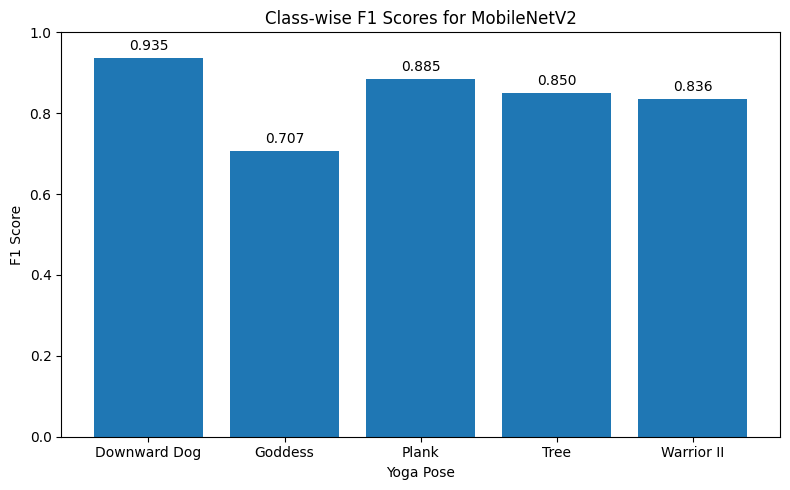

Class-wise F1 score figure saved.


In [17]:
# ============================================================
# Cell 16: Class-wise F1 Scores
# ============================================================

f1_df = report_df.loc[
    [display_names[c] for c in class_names],
    ["f1-score"]
].reset_index()

f1_df.columns = ["Class", "F1 Score"]

display(f1_df)

f1_df.to_excel(
    os.path.join(RESULT_DIR, "classwise_f1_scores.xlsx"),
    index=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    f1_df["Class"],
    f1_df["F1 Score"]
)

plt.title("Class-wise F1 Scores for MobileNetV2")
plt.xlabel("Yoga Pose")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "classwise_f1_scores.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class-wise F1 score figure saved.")

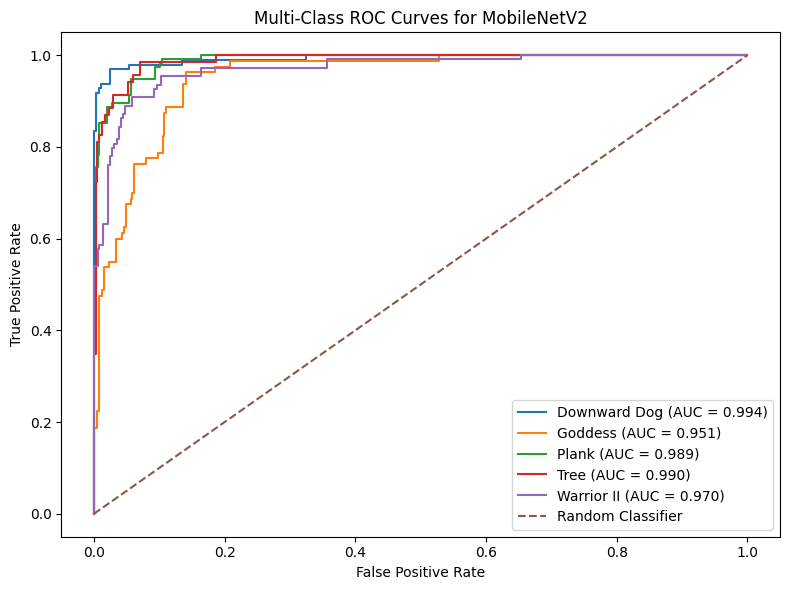

,Class,ROC-AUC
0,Downward Dog,0.993560
1,Goddess,0.951410
2,Plank,0.988830
3,Tree,0.989591
4,Warrior II,0.970495


Multi-class ROC curve figure and ROC-AUC table saved.


In [18]:
# ============================================================
# Multi-Class ROC Curves for MobileNetV2
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(
    y_true,
    classes=list(range(NUM_CLASSES))
)

roc_results = []

plt.figure(figsize=(8, 6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    roc_results.append({
        "Class": display_names[cls],
        "ROC-AUC": roc_auc
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{display_names[cls]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("Multi-Class ROC Curves for MobileNetV2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "mobilenetv2_multiclass_roc_curves.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

roc_df = pd.DataFrame(roc_results)
display(roc_df)

roc_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_roc_auc_scores.xlsx"),
    index=False
)

print("Multi-class ROC curve figure and ROC-AUC table saved.")

In [19]:
# ============================================================
# Cell 17: Create README and Export Project
# ============================================================

readme_text = f"""
# Yoga Pose Classification Using Convolutional Neural Networks and Transfer Learning

## Project Overview

This project classifies five yoga poses using deep learning:

- Custom CNN
- MobileNetV2 Transfer Learning

## Yoga Pose Classes

- Downward Dog
- Goddess
- Plank
- Tree
- Warrior II

## Final Model Performance

| Model | Test Accuracy (%) | Test Loss |
|---|---:|---:|
| Custom CNN | {custom_acc * 100:.2f} | {custom_loss:.4f} |
| MobileNetV2 | {mobile_acc * 100:.2f} | {mobile_loss:.4f} |

## Repository Contents

- `Figures/`: PDF result figures
- `Models/`: Trained Keras models
- `Results/`: Excel and CSV result files
- `Notebook/`: Kaggle notebook with code and visible outputs

## Key Outputs

- Dataset characterization
- Data augmentation examples
- CNN and MobileNetV2 training curves
- Confusion matrix
- Classification report
- Class-wise F1 score analysis
- Detailed mixed prediction analysis
"""

with open(os.path.join(PROJECT_DIR, "README.md"), "w") as f:
    f.write(readme_text)

zip_path = "/kaggle/working/Yoga-Pose-Recognition.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    PROJECT_DIR
)

print("README created.")
print("Project ZIP created:")
print(zip_path)

README created.
Project ZIP created:
/kaggle/working/Yoga-Pose-Recognition.zip


# ============================================================
# Missing Figure: Overall Workflow Diagram
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")

def add_box(x, y, w, h, text, color):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.15,rounding_size=0.12",
        linewidth=1.8,
        edgecolor="black",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.8,
        color="black"
    )
    ax.add_patch(arrow)

# Row 1: Dataset and preprocessing
add_box(0.5, 6.2, 2.0, 0.9, "1. Yoga Pose\nDataset", "#BDE0FE")
add_box(3.0, 6.2, 2.0, 0.9, "2. Dataset\nCleaning", "#CDB4DB")
add_box(5.5, 6.2, 2.0, 0.9, "3. Dataset\nAnalysis", "#FFC8DD")
add_box(8.0, 6.2, 2.0, 0.9, "4. Image\nPreprocessing", "#FFAFCC")
add_box(10.5, 6.2, 2.0, 0.9, "5. Data\nAugmentation", "#A2D2FF")

add_arrow(2.5, 6.65, 3.0, 6.65)
add_arrow(5.0, 6.65, 5.5, 6.65)
add_arrow(7.5, 6.65, 8.0, 6.65)
add_arrow(10.0, 6.65, 10.5, 6.65)

# Down arrow
add_arrow(11.5, 6.2, 11.5, 4.8)

# Row 2: Models
add_box(9.7, 3.8, 2.3, 0.9, "6. Custom CNN\nBaseline Model", "#CAFFBF")
add_box(6.7, 3.8, 2.3, 0.9, "7. MobileNetV2\nTransfer Learning", "#FDFFB6")
add_box(3.7, 3.8, 2.3, 0.9, "8. Model\nTraining", "#FFD6A5")
add_box(0.7, 3.8, 2.3, 0.9, "9. Checkpoints\nand Logs", "#E9C46A")

add_arrow(9.7, 4.25, 9.0, 4.25)
add_arrow(6.7, 4.25, 6.0, 4.25)
add_arrow(3.7, 4.25, 3.0, 4.25)

# Down arrow to evaluation
add_arrow(1.85, 3.8, 1.85, 2.6)

# Row 3: Evaluation
add_box(0.7, 1.4, 2.3, 0.9, "10. Model\nEvaluation", "#B9FBC0")
add_box(3.7, 1.4, 2.3, 0.9, "11. Confusion\nMatrix", "#98F5E1")
add_box(6.7, 1.4, 2.3, 0.9, "12. Model\nComparison", "#8ECAE6")
add_box(9.7, 1.4, 2.3, 0.9, "13. Best Model\nSelection", "#90DBF4")

add_arrow(3.0, 1.85, 3.7, 1.85)
add_arrow(6.0, 1.85, 6.7, 1.85)
add_arrow(9.0, 1.85, 9.7, 1.85)

plt.title(
    "Overall Workflow for Yoga Pose Classification Using CNN and Transfer Learning",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "overall_workflow_diagram.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Overall workflow diagram saved.")